### Modelo Forecasting Familias 
## Objetivo del Script
El script tiene como objetivo predecir la demanda de productos en Sodimac mediante la construcción de un modelo de forecasting basado en variables internas y factores externos (marco). Se busca anticipar el volumen de venta por familia a partir de las variables.


__Ultima Version: 10-12-2024.__<br>
__Changelog:__
* 1) REENTRENAR CON TODO EL SET DE VARIABLES EXCLUYENDO:
- Colocaciones consumo, desempleo, desempleo EEUU, IRPV Casa, Oil, Diesel, Stock Viviendas, Tasa int_ex_pol_monetaria_EEUU y Tasas_int_sis_financiero
Y AUMENTAR LOS TRIALS DE OPTUNA EN LOS MODELOS MALOS (especial foco en Puertas, Muebles y Pinturas)
- Utilizar solo SK, Prophet y HW
* 2) EN FAMILIAS QUE SIGAN MALAS: Entrenar sin pandemia y devolvemos todas las variables.



## 1. Importacion Librerias

In [42]:
import pickle
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from io import BytesIO
import base64
from soditools import soditools as u
import pandas as pd 
from Sodi_Forecast import read_sql_file
import copy
from models import *
from aux import (
    format_as_year_month,
    detect_outlier,
    limpiar_outliers_x_agrupacion,
    feature_selection,
    eliminar_sufixo,
    collinearity_analysis,
    clean_focus_correlation,
    plot_series_with_lag,
    ARIMA_datos_faltantes,
    encontrar_primera_secuencia_continua
)
from itertools import combinations
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore")
%matplotlib inline
max_year = 2025
max_month =1
exog_diego=u.query("select * from sod-cl-bi-sandbox.project_forecast_macro.preprocess_exog_var")
exog_diego.index = pd.to_datetime(exog_diego.dt)
exog_diego = exog_diego.resample('MS').last()
exog_diego.drop(columns=['dt'],inplace=True)
exog_diego.index = exog_diego.index.tz_localize(None)

sales_by_family = u.query(read_sql_file("./sql/sales_by_family.sql").replace("{max_year}",str(max_year)).replace("{max_month}",str(max_month)))
quiebre_stock=u.query("select * from sod-cl-bi-sandbox.project_forecast_macro.quiebre_stock")
importaciones=u.query("select * from sod-cl-bi-sandbox.project_forecast_macro.datasur")
competidores_por_familia=u.query("select * from sod-cl-bi-sandbox.project_forecast_macro.Market_Competition_per_family")
preprocess_diego=u.query("select * from sod-cl-bi-sandbox.project_forecast_macro.preprocess_exog_fam_var")
familias=u.query(read_sql_file("./sql/familias.sql"))
IAC=pd.read_excel('series IAC.xlsx', sheet_name = 'rojas_asociados_reformated', index_col='dt', parse_dates=True).loc['2016-01-01':'2024-12-31']
IAC = IAC.resample('MS').last()
exog_diego= exog_diego.join(IAC)
data_by_family = {}
for family in sales_by_family['family'].unique():
    aux = sales_by_family[sales_by_family['family'] == family].copy()
    #aux = aux.merge(avg_price, how='left', on=['year', 'month', 'family'])
    #aux = aux.merge(quiebres, how='left', on=['year', 'month', 'family'])
    aux = format_as_year_month(aux)
    data_by_family[family] = aux

data_by_family_imputado =  copy.deepcopy(data_by_family)
for family in data_by_family.keys():
    d = data_by_family_imputado[family]
    d_imputado, idx_outliers = limpiar_outliers_x_agrupacion(d, 'family', 'sale_amount_MM')
    data_by_family_imputado[family].loc[:,'sale_amount_MM'] = d_imputado['sale_amount_MM']
exog_diego.ffill(inplace=True)
exog_diego['Verano']= exog_diego['Verano'].astype(float)
exog=exog_diego

>> Query will process 0.00011944770812988281 GB and cost USD 1e-06 <<
>> Query took 2 seconds <<
>> Query will process 0.0002796761691570282 GB and cost USD 1e-06 <<
>> Query took 2 seconds <<
>> Query will process 4.7847628593444824e-05 GB and cost USD 0.0 <<
>> Query took 2 seconds <<
>> Query will process 0.013891458511352539 GB and cost USD 6.8e-05 <<
>> Query took 2 seconds <<
>> Query will process 1.9632279872894287e-06 GB and cost USD 0.0 <<
>> Query took 2 seconds <<
>> Query will process 9.459257125854492e-05 GB and cost USD 0.0 <<
>> Query took 2 seconds <<
>> Query will process 0.11799527145922184 GB and cost USD 0.000575 <<
>> Query took 2 seconds <<


In [43]:
!python --version

Python 3.7.12


In [49]:
data_by_family[name]

,year,month,family,sale_amount_MM
yearmon,,,,
2017-01-01,2017,1,0316,7382.237275
2017-02-01,2017,2,0316,4203.050913
2017-03-01,2017,3,0316,5425.725306
2017-04-01,2017,4,0316,7387.675291
2017-05-01,2017,5,0316,13103.923203
...,...,...,...,...
2024-08-01,2024,8,0316,8324.027866
2024-09-01,2024,9,0316,7988.202699
2024-10-01,2024,10,0316,8299.753819


## 4. Seleccion Variables

In [ ]:
import pickle
from IPython.display import display, HTML


def train_models(name,target_col,exog):
    exog = exog.drop('quiebre_stock', axis=1, errors='ignore')
    fam_quiebre_stock=preprocess_diego.copy()
    fam_quiebre_stock['periodo']=pd.to_datetime(fam_quiebre_stock.dt).dt.date
    fam_quiebre_stock=fam_quiebre_stock[fam_quiebre_stock.hier_family_cd==name].sort_values('periodo')[['periodo','quiebre_stock']]
    exog=exog.join(fam_quiebre_stock.drop('periodo', axis=1, errors='ignore'))
    exog['quiebre_stock']=ARIMA_datos_faltantes(pd.DataFrame(exog['quiebre_stock']))
    ### Variable Importaciones
    exog = exog.drop('Importaciones_Fam_FOB', axis=1, errors='ignore')
    exog = exog.drop('Importaciones_Fam_CIF', axis=1, errors='ignore')
    exog = exog.drop('FOB_Total', axis=1, errors='ignore')
    exog = exog.drop('CIF_Total', axis=1, errors='ignore')
    Importaciones_Fam=preprocess_diego.copy()
    Importaciones_Fam['periodo']=pd.to_datetime(Importaciones_Fam.dt).dt.date
    Importaciones_Fam=Importaciones_Fam[Importaciones_Fam.hier_family_cd==name].sort_values('periodo')[['periodo','FOB_Total','CIF_Total']]
    Importaciones_Fam=Importaciones_Fam.fillna(0)
    Importaciones_Fam=Importaciones_Fam.set_index('periodo')
    Importaciones_Fam.index = pd.to_datetime(Importaciones_Fam.index)
    Importaciones_Fam.index.name = "dt"
    exog=exog.join(Importaciones_Fam.drop('periodo', axis=1, errors='ignore'))

    
    feat_select=feature_selection(data_by_family[name],exog,corte=0.6,max_lag=4,min_lag=-3,target_col=target_col,
                                  ignore_col=['units_sold', 'avg_price', 'family', 'total_UCI',
                                              'retiro 1', 'retiro 2', 'retiro 3','feriados','dias_del_mes'],
                                  negatives_reg_col=[
                                               'Primavera','Verano','Otono', 'Halloween','Navidad','Fiestas_patrias','Dia_mama',
                                               'san_valentin','Norte_tavg','Norte_prcp','Norte_wspd','Centro_tavg','Centro_prcp',
                                              'Centro_wspd','Sur_tavg','Sur_prcp','Sur_wspd','ExtremoSur_tavg','ExtremoSur_prcp',
                                                 'ExtremoSur_wspd', 'cyber','cyber_pct_mes'] )
    feat_select=pd.DataFrame(feat_select).reset_index(drop=True)
    feat_select=clean_focus_correlation(pd.DataFrame(feat_select),group='variable',focus='correlación')
    feat_select=feat_select.reindex(feat_select['correlación'].abs().sort_values(ascending=False).index)
    feat_select=feat_select.reset_index().drop(columns=['index'], errors='ignore')
    #print("__________________")
    #if name=='0328':
       # df_target=pd.concat([data_by_family['0102'],data_by_family[name]])
      #  df_target['family']='0328'
    #else:
    df_target=data_by_family[name]
    corte_correl=0.7
    selected_colinealidad=collinearity_analysis(df_target, exog, feat_select, target_col, corte_correl)
    feat_select=feat_select.iloc[np.where(np.isin(feat_select.variable,selected_colinealidad))]
    #print("resultados colinealidad")
    #print(feat_select)
    ##MODELO SELECCION CARACTERISTICAS
    target_col='sale_amount_MM'
    data_selection=data_by_family[name].copy()
    data_selection['ds'] = data_selection.index
    data_selection['y'] = data_selection[target_col]
    top_features = feat_select.copy()
    lagged_df = pd.DataFrame(index=exog.index)

    def evaluate_model(df_seleccion,y,features):
        X = df_seleccion[features]
        X = sm.add_constant(X)
        model = sm.OLS(y, X).fit() 
        aic = model.aic 
        performance = model.rsquared_adj 
        return aic, performance


    def multreg_feature_selection(data_selection,lagged_df,top_features):
        for _, row in top_features.iterrows():
            variable = row['variable']
            lag = row['lag']
            # Generar el nombre de la columna con lag
            col_name = f"{variable}_lag{lag}"
            # Si la variable existe en exog_df, aplicamos el lag y lo agregamos a lagged_df
            if variable in exog.columns:
                lagged_df[col_name] = exog[variable].shift(lag)
        df_seleccion = data_selection.drop(['year', 'month'], axis=1).join(lagged_df, how='inner')
        df_seleccion.index = pd.to_datetime(df_seleccion.index)
        #Importaciones_Fam.index.name = "dt"
        df_seleccion=df_seleccion.loc['2017-01-01':'2024-07-01']
        df_seleccion=df_seleccion.drop(['family', 'ds','sale_amount_MM'], axis=1)
        df_seleccion.dropna(inplace=True)
        y = df_seleccion['y'] 
        variables = [col for col in df_seleccion.columns if col != 'y']
        results = []

        for i in range(1, len(variables) + 1):
            for combo in combinations(variables, i):
                aic, performance = evaluate_model(df_seleccion,y,list(combo))
                results.append({
                    'combination': combo,
                    'aic': aic,
                    'performance': performance
                })
        results_df = pd.DataFrame(results)
        results_df['n feat']=len(results_df['combination'])
        results_df['ranking'] = results_df['aic'].rank(method='min') + results_df['n feat'].rank(ascending=False, method='min')
        results_df = results_df.sort_values(by='ranking', ascending=True).reset_index(drop=True)
        feat_select=top_features.iloc[np.where(np.isin(top_features.variable,[i.split('_lag')[0] for i in results_df.combination.iloc[0]]).tolist())]
        return(feat_select,results_df)



    feat_select_aic,results_df=multreg_feature_selection(data_selection,lagged_df,top_features)
    #feat_select_aic=feat_select_aic[feat_select_aic['correlación']>=0.5]
    #feat_select_aic.loc[feat_select_aic['variable'] == 'IAC_Ferreteria_Mayorista', 'variable'] = 'IAC_Electricos_y_Hogar'

    #nuevo_registro = {"lag": 0, "variable": "IAC_Electricos_y_Hogar", "correlación": 1}
    #feat_select_aic = pd.concat([feat_select_aic, pd.DataFrame([nuevo_registro])], ignore_index=True)
    #feat_select_aic = feat_select_aic[feat_select_aic['variable'] != 'IAC_Ferreteria_Minorista']
    
    display(HTML(f"""
    <div style="display: flex; gap: 20px;">
        <div>{feat_select.to_html()}</div>
        <div>{results_df.iloc[0:10].to_html()}</div>
        <div>{feat_select_aic.to_html()}</div>
    </div>
    """))
    #with open('./Resultados Familias/results'+name+'.pkl', 'rb') as file:
    #    file = pickle.load(file)
    #results={}
    #results['trials']=file['trials']
    #esults['features']=feat_select_aic
    #with open('./Resultados Familias/results'+name+'.pkl', 'wb') as file:
    #    pickle.dump(results, file)
    ### EJECUCION MODELO
    #print("__________________")
    #if name=='0328':
      #  family=pd.concat([data_by_family['0102'],data_by_family[name]])
      #  family['family']='0328'
    #else:
    family=data_by_family[name]

    #family=data_by_family[name].copy()
    family['ds'] = family.index
    family['y'] = family[target_col]
    df = family.drop(['year', 'month'], axis=1).join(exog[list(feat_select_aic.variable)].copy(), how='inner')
    df.index = pd.to_datetime(df.index)
    df=df.loc['2017-01-01':'2024-07-01']
    
    df_regressors = pd.DataFrame()
    for index, row in feat_select_aic.iterrows():
           df_regressors[row['variable'] +'_lag_' + str(row['lag'])] = df[row['variable']].shift(row['lag'])
    df =df[['ds','y']].join(df_regressors.dropna())
    df.columns = df.columns.str.replace(' ', '_')
    df.columns = df.columns.str.replace('/', '_')
    df.columns = df.columns.str.replace('-', '_')
    df = df.dropna()
    test_periods =12
    #training_set = df[:-test_periods]
    #test_set = df[-test_periods:]
    np.random.seed(12)
    #n_max = df.shape[0] - test_periods
    #split = [(list(range(0 ,n_max - (test_periods - 1) - 6* i)), list(range(n_max  - (test_periods - 1) - 6* i, n_max -  6 *i))) for i in range(0, 5)]
    #split.extend([(list(range(0, n_max)), list(range(n_max, n_max + test_periods)))])

    test_periods = 12  
    train_periods = 72 
    #train_periods = df.index.get_loc("2022-12-01")+1
    split = []
    split=[(list(range(i, i + train_periods)),list(range(i + train_periods, i + train_periods + test_periods))) for i in range(0,19) if (i + train_periods + test_periods - 1) < len(df)]
    ##training_set=df.iloc[split[0][0]]
    ##test_set=df.iloc[split[0][1]]
    ##model, y_pred = fit_predict_eval_sarimax(training_set, test_set, model_params=None)
    #df = df.rename_axis("ds", axis="index")
    ### EJECUCION MODELO
    #print("__________________")
    #if name=='0328':
     #   family=pd.concat([data_by_family['0102'],data_by_family[name]])
     #   family['family']='0328'
   # else:
    family=data_by_family[name]

    #family=data_by_family[name].copy()
    family['ds'] = family.index
    family['y'] = family[target_col]
    df = family.drop(['year', 'month'], axis=1).join(exog[list(feat_select_aic.variable)].copy(), how='inner')
    df.index = pd.to_datetime(df.index)
    df=df.loc['2017-01-01':'2024-07-01']
    df_regressors = pd.DataFrame()
    for index, row in feat_select_aic.iterrows():
           df_regressors[row['variable'] +'_lag_' + str(row['lag'])] = df[row['variable']].shift(row['lag'])
    df =df[['ds','y']].join(df_regressors.dropna())
    df.columns = df.columns.str.replace(' ', '_')
    df.columns = df.columns.str.replace('/', '_')
    df.columns = df.columns.str.replace('-', '_')
    df = df.dropna()
    #training_set = df[:-test_periods]
    #test_set = df[-test_periods:]
    np.random.seed(12)
    #n_max = df.shape[0] - test_periods
    #split = [(list(range(0 ,n_max - (test_periods - 1) - 6* i)), list(range(n_max  - (test_periods - 1) - 6* i, n_max -  6 *i))) for i in range(0, 5)]
    #split.extend([(list(range(0, n_max)), list(range(n_max, n_max + test_periods)))])
    test_periods = 12  
    train_periods = 72 
    #train_periods = df.index.get_loc("2022-12-01")+1
    split = []
    split=[(list(range(i, i + train_periods)),list(range(i + train_periods, i + train_periods + test_periods))) for i in range(0,19) if (i + train_periods + test_periods - 1) < len(df)]
    ##training_set=df.iloc[split[0][0]]
    ##test_set=df.iloc[split[0][1]]
    ##model, y_pred = fit_predict_eval_sarimax(training_set, test_set, model_params=None)
    #df = df.rename_axis("ds", axis="index")
    trials=250
    best_params_prophet, trials_df_prophet,model_dict_prophet=optimize_prophet_cv(df, split, n_trials=trials)
    trials_df_prophet['model']='prophet'
    best_params_silverkite, trials_df_silverkite,model_dict_silverkite=optimize_silverkite_cv(df, split, n_trials=trials)
    trials_df_silverkite['model']='silverkite'
  #  best_params_tbats, trials_df_tbats,model_dict_tbats=optimize_tbats_cv(df, split, n_trials=2)
    #trials_df_tbats['model']='tbats'
   # best_params_sarimax, trials_df_sarimax,model_dict_sarimax=optimize_sarimax_cv(df, split, n_trials=trials)
   # trials_df_sarimax['model']='sarimax'
    best_params_hw, trials_df_hw,model_dict_hw=optimize_hw_cv(df, split, n_trials=trials)
    trials_df_hw['model']='holt_winters'
   # best_params_enet, trials_df_enet, model_dict_enet=optimize_elastic_net_cv(df, split, n_trials=trials)
    #trials_df_enet['model']='elastic_net'
    #best_params_mlp, trials_df_mlp, model_dict_mlp=optimize_mlp_cv(df, split, n_trials=trials)
   # trials_df_mlp['model']='mlp'
   # best_params_ets, trials_df_ets, model_dict_ets=optimize_ets_cv(df, split, n_trials=trials)
  # trials_df_ets['model']='ets'


    results={}
    results['trials']=pd.concat([
              trials_df_hw,
       # trials_df_tbats,
            #   trials_df_sarimax,
               trials_df_silverkite,
               trials_df_prophet,
              # trials_df_mlp,
              # trials_df_enet,
              # trials_df_ets,
      #  trials_df_tbats
    ])
    results['features']=feat_select_aic
    with open('./reentrenamientos 8 feb iac/results'+name+'.pkl', 'wb') as file:
        pickle.dump(results, file)


In [ ]:

names=['0522']
target_col='sale_amount_MM'
for i in names:
    train_models(i,target_col,exog)

In [22]:
name='0316'
exog = exog.drop('quiebre_stock', axis=1, errors='ignore')
fam_quiebre_stock=preprocess_diego.copy()
fam_quiebre_stock['periodo']=pd.to_datetime(fam_quiebre_stock.dt).dt.date
fam_quiebre_stock=fam_quiebre_stock[fam_quiebre_stock.hier_family_cd==name].sort_values('periodo')[['periodo','quiebre_stock']]
exog=exog.join(fam_quiebre_stock.drop('periodo', axis=1, errors='ignore'))
exog['quiebre_stock']=ARIMA_datos_faltantes(pd.DataFrame(exog['quiebre_stock']))
### Variable Importaciones
exog = exog.drop('Importaciones_Fam_FOB', axis=1, errors='ignore')
exog = exog.drop('Importaciones_Fam_CIF', axis=1, errors='ignore')
exog = exog.drop('FOB_Total', axis=1, errors='ignore')
exog = exog.drop('CIF_Total', axis=1, errors='ignore')
Importaciones_Fam=preprocess_diego.copy()
Importaciones_Fam['periodo']=pd.to_datetime(Importaciones_Fam.dt).dt.date
Importaciones_Fam=Importaciones_Fam[Importaciones_Fam.hier_family_cd==name].sort_values('periodo')[['periodo','FOB_Total','CIF_Total']]
Importaciones_Fam=Importaciones_Fam.fillna(0)
Importaciones_Fam=Importaciones_Fam.set_index('periodo')
Importaciones_Fam.index = pd.to_datetime(Importaciones_Fam.index)
Importaciones_Fam.index.name = "dt"
exog=exog.join(Importaciones_Fam.drop('periodo', axis=1, errors='ignore'))

In [24]:
exog.info

<bound method DataFrame.info of                   oil        al        zn      cu     cotton           au  \
dt                                                                          
2017-01-01  52.810000  0.824864  1.300817  2.7745  74.970000  1212.815937   
2017-02-01  54.010000  0.873412  1.279946  2.7760  76.310000  1246.553066   
2017-03-01  50.600000  0.891221  1.255898  2.7420  77.330000  1249.285714   
2017-04-01  49.330000  0.867173  1.190336  2.6810  78.770000  1270.071013   
2017-05-01  48.320000  0.874660  1.179673  2.6575  76.930000  1268.886005   
...               ...       ...       ...     ...        ...          ...   
2024-08-01  73.550003  1.062840  1.130469  4.1450  69.790001  2502.414027   
2024-09-01  68.169998  1.149841  1.142813  4.4960  73.559998  2632.706856   
2024-10-01  69.260002  1.161751  1.104688  4.3135  69.570000  2720.950000   
2024-11-01  68.000000  1.162432  1.110156  4.0805  73.349998  2651.431078   
2024-12-01  71.720001  1.144170  1.087500  3

In [26]:
exog = exog.drop('quiebre_stock', axis=1, errors='ignore')
fam_quiebre_stock=quiebre_stock.copy()
fam_quiebre_stock['periodo']=pd.to_datetime(fam_quiebre_stock.copy().periodo)
fam_quiebre_stock=fam_quiebre_stock[fam_quiebre_stock.hier_family_cd==name].sort_values('periodo')[['periodo','perc_zero_stock']].rename(columns={'periodo':'dt','perc_zero_stock': 'quiebre_stock'}).set_index('dt')
exog=exog.join(fam_quiebre_stock)
exog['quiebre_stock']=ARIMA_datos_faltantes(pd.DataFrame(exog['quiebre_stock']))

### Variable Importaciones
exog = exog.drop('Importaciones_Fam_FOB', axis=1, errors='ignore')
exog = exog.drop('Importaciones_Fam_CIF', axis=1, errors='ignore')
exog = exog.drop('FOB_Total', axis=1, errors='ignore')
exog = exog.drop('CIF_Total', axis=1, errors='ignore')
try:
    Competidores_Fam=list(competidores_por_familia[competidores_por_familia.Family==name].Rut.unique())
except:
    Competidores_Fam=list(competidores_por_familia.Rut.unique())

Importaciones_Fam=importaciones.iloc[np.where(np.isin(importaciones.rut,Competidores_Fam)) ].sort_values(by='periodo')
Importaciones_Fam['periodo']=pd.to_datetime(Importaciones_Fam.periodo)
Importaciones_Fam_FOB=pd.DataFrame(Importaciones_Fam.groupby('periodo').FOB.sum()).rename(columns={'FOB': 'FOB_Total'})
Importaciones_Fam_CIF=pd.DataFrame(Importaciones_Fam.groupby('periodo').CIF.sum()).rename(columns={'CIF': 'CIF_Total'})
Importaciones_Fam_FOB.index.rename('dt', inplace=True)
Importaciones_Fam_CIF.index.rename('dt', inplace=True)
Importaciones_Fam_FOB=Importaciones_Fam_FOB.fillna(0)
Importaciones_Fam_CIF=Importaciones_Fam_CIF.fillna(0)
exog=exog.join(Importaciones_Fam_FOB)
exog=exog.join(Importaciones_Fam_CIF)

## Seleccion de Caracteristicas
exog=exog
feat_select=feature_selection(data_by_family[name],exog,corte=0.2,max_lag=4,min_lag=-3,target_col=target_col,
                              ignore_col=['units_sold', 'avg_price', 'family', 'total_UCI',
                                          'retiro 1', 'retiro 2', 'retiro 3','feriados','dias_del_mes'],
                              negatives_reg_col=[
                                           'Primavera','Verano','Otono', 'Halloween','Navidad','Fiestas_patrias','Dia_mama',
                                           'san_valentin','Norte_tavg','Norte_prcp','Norte_wspd','Centro_tavg','Centro_prcp',
                                          'Centro_wspd','Sur_tavg','Sur_prcp','Sur_wspd','ExtremoSur_tavg','ExtremoSur_prcp',
                                             'ExtremoSur_wspd', 'cyber','cyber_pct_mes'] )
feat_select=pd.DataFrame(feat_select).reset_index(drop=True)
feat_select=clean_focus_correlation(pd.DataFrame(feat_select),group='variable',focus='correlación')
feat_select=feat_select.reindex(feat_select['correlación'].abs().sort_values(ascending=False).index)
feat_select=feat_select.reset_index().drop(columns=['index'], errors='ignore')

In [28]:
feat_select[feat_select.variable=='IAC_Electricos_y_Hogar']

,lag,variable,correlación
61,0,IAC_Electricos_y_Hogar,0.233104


In [199]:
results={}
results['trials']=pd.concat([
           #trials_df_hw,
           #trials_df_sarimax,
           #trials_df_silverkite,
           trials_df_prophet,
           #trials_df_mlp,
           #trials_df_enet,
           #trials_df_ets
                            ])
results['features']=feat_select_aic

In [227]:
name='0101'

In [ ]:
import pickle
name='0522'
with open('./Resultados Familias/results'+name+'.pkl', 'rb') as file:
    loaded_dict = pickle.load(file)['trials']
loaded_dict

In [62]:
training_set=df.copy().loc['2017-05-01':'2023-08-01']
test_set=df.copy().loc['2023-09-01'::]
#models_results=results['trials'].reset_index()
models_results=loaded_dict.reset_index()
models_results = models_results.loc[models_results.groupby('model')['mape_mean'].idxmin()]


In [63]:
training_set=df.copy().loc['2017-05-01':'2023-08-01']
test_set=df.copy().loc['2023-09-01'::]
#models_results=results['trials'].reset_index()
models_results=loaded_dict.reset_index()
models_results = models_results.loc[models_results.groupby('model')['mape_mean'].idxmin()]

dict_mape = {}
list_mape = []
list_mape_completa = []
model_df=pd.DataFrame([])
funcs = dict(zip(['holt_winters','elastic_net','prophet','mlp','sarimax','silverkite','ets'],
                     [fit_predict_eval_hw,fit_predict_eval_elastic_net,fit_predict_eval_prophet,
                      fit_predict_eval_mlp,fit_predict_eval_sarimax,fit_predict_eval_silverkite,fit_predict_eval_ets]))
model_params=None
prediciones=pd.DataFrame(test_set['y'])
df=pd.concat([training_set,test_set],axis=0)
df=df.drop(list(funcs.keys()), axis=1, errors='ignore')
for label, func in funcs.items():
            model_params = list(models_results[models_results.model==label].params.values)
           # params = None
            model, y_pred = func(training_set, test_set, model_params[0])
            y_pred.index = test_set.index
            y_pred=pd.DataFrame(y_pred)
            y_pred.index.name = 'ds'
            y_pred=y_pred.drop('ds', axis=1, errors='ignore')
            y_pred.columns=[label]
            prediciones=prediciones.join(y_pred)
            try:
                mape = mean_absolute_percentage_error(test_set['y'], np.maximum(0,y_pred))
            except:
                mape = np.nan

            list_mape.append([label,mape])


15:27:09 - cmdstanpy - INFO - Chain [1] start processing
15:27:09 - cmdstanpy - INFO - Chain [1] done processing


Fitting 2 folds for each of 1 candidates, totalling 2 fits


## 6. Plot Series

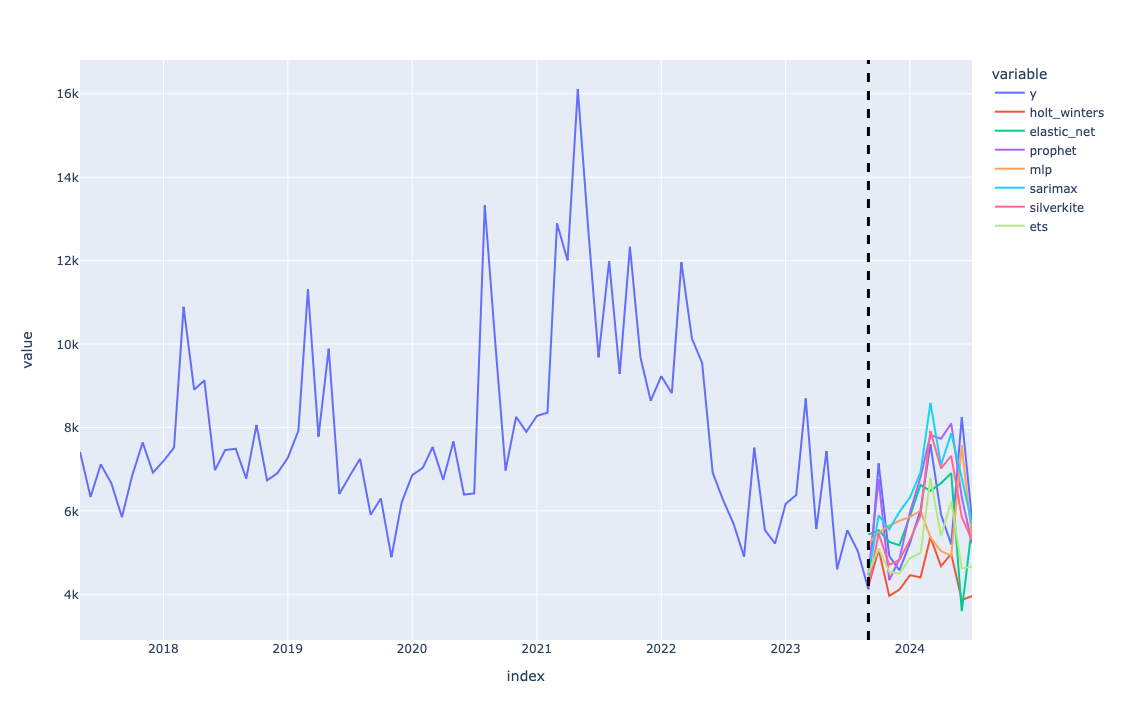

,trial_number,params,mape_mean,mape_best,mape_test
model,,,,,
elastic_net,24,"{'alpha': 2.98068283076335e-05, 'l1_ratio': 0....",0.158062,0.137957,0.196260
ets,10,"{'error': 'mul', 'trend': 'add', 'seasonal': '...",0.150918,0.093665,0.158170
holt_winters,14,"{'trend': 'add', 'seasonal': 'mul', 'seasonal_...",0.176632,0.118275,0.219502
mlp,13,"{'hidden_layer_sizes': (64, 32), 'max_iter': 800}",0.175382,0.141497,0.153265
prophet,23,"{'growth': 'flat', 'seasonality_prior_scale': ...",0.110038,0.063888,0.165193
sarimax,12,"{'p': 0, 'd': 1, 'q': 3, 'P': 1, 'D': 0, 'Q': ...",0.151217,0.111952,0.189969
silverkite,1,"{'growth': 'linear', 'fit_algorithm': 'ridge',...",0.120862,0.096596,0.127575


In [64]:
#plot Funciones
prediciones=prediciones.drop('y', axis=1, errors='ignore')
test=pd.DataFrame(list_mape, columns=['model', 'mape_test']).set_index('model')
time_series=pd.DataFrame(pd.DataFrame(df['y']).join(prediciones))
fig = px.line(time_series, y=time_series.columns)
fig.add_vline(x=test_set.index[0], line_width=3, line_dash="dash", line_color="black")
fig.show()
models_results.set_index('model')[['trial_number','params','mape_mean','mape_best']].join(test)

In [ ]:
model, y_pred = fit_predict_eval_elastic_net(training_set, test_set, model_params[0])

def predict_hw(model, test_set):
    y_pred = pd.Series(model.predict(start=test_set.index[0],end=test_set.index[-1])).rename('ETS')
    return y_pred

def predict_enet(model,test_set):
    y_pred = model.predict(test_set)
    forecast_test_df = pd.DataFrame({date_col: test_set[date_col].values,'pred_test': y_pred})

predict_enet(model,df.copy()['y'])

In [ ]:
import zipfile
import os

# Ruta de la carpeta que deseas comprimir
carpeta_origen = './Resultados Familias'

# Ruta del archivo zip de salida
archivo_zip = './respaldo_resultados_familias-7ene.zip'

# Verificar si la carpeta de salida existe, si no, crearla
carpeta_destino = os.path.dirname(archivo_zip)  # Extraer la ruta de la carpeta
if not os.path.exists(carpeta_destino):
    os.makedirs(carpeta_destino)
    print(f"Se creó la carpeta destino: {carpeta_destino}")

# Verificar si la carpeta de origen existe
if os.path.exists(carpeta_origen) and os.path.isdir(carpeta_origen):
    # Crear el archivo zip
    with zipfile.ZipFile(archivo_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(carpeta_origen):
            for file in files:
                # Agregar cada archivo al zip, manteniendo la estructura de carpetas
                ruta_completa = os.path.join(root, file)
                ruta_relativa = os.path.relpath(ruta_completa, carpeta_origen)
                zipf.write(ruta_completa, ruta_relativa)
    print(f"Archivo comprimido creado: {archivo_zip}")
else:
    print(f"La carpeta {carpeta_origen} no existe o no es válida.")